## 7. Comparaison finale et analyse

### 7.1 Tableau récapitulatif

In [1]:
import pandas as pd

data = {
    "Modèle": ["MLP", "CNN", "Transfer Learning", "ViT"],
    "Nombre de paramètres": [
        "à compléter",
        "391177",
        "à compléter",
        "552585"
    ],
    "Accuracy test": [
        "à compléter",
        "90.13%",
        "à compléter",
        "79.53%"
    ],
    "Temps d'entraînement": [
        "rapide",
        "moyen",
        "rapide",
        "long"
    ]
}

df = pd.DataFrame(data)
df

,Modèle,Nombre de paramètres,Accuracy test,Temps d'entraînement
0,MLP,à compléter,à compléter,rapide
1,CNN,391177,90.13%,moyen
2,Transfer Learning,à compléter,à compléter,rapide
3,ViT,552585,79.53%,long


In [14]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)

Device utilisé : cpu


In [18]:
class HistologyCNN(nn.Module):
    def __init__(self):
        super(HistologyCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 9)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [19]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_dataset = PathMNIST(split='test', transform=transform_test, download=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Nombre d'images test :", len(test_dataset))

Nombre d'images test : 7180


In [20]:
model = HistologyCNN().to(device)
model.load_state_dict(torch.load("model_aug_pathmnist.pth", map_location=device))
model.eval()

print("Modèle chargé avec succès")

Modèle chargé avec succès


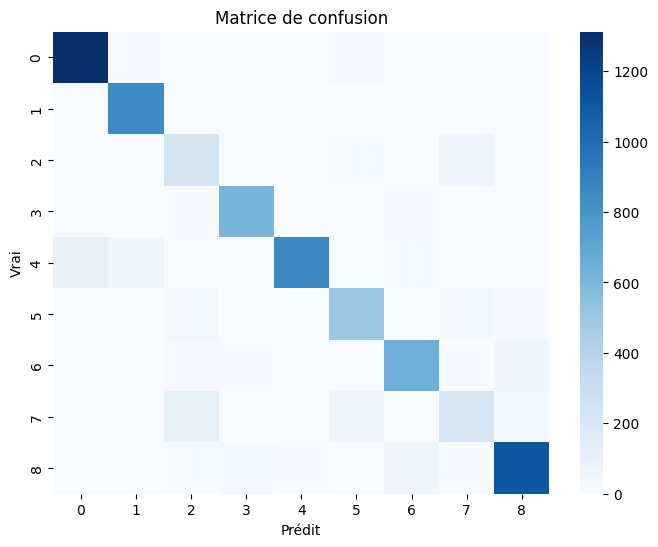

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1338
           1       0.92      1.00      0.96       847
           2       0.56      0.71      0.63       339
           3       0.94      0.97      0.95       634
           4       0.97      0.82      0.89      1035
           5       0.83      0.85      0.84       592
           6       0.89      0.87      0.88       741
           7       0.64      0.52      0.57       421
           8       0.92      0.90      0.91      1233

    accuracy                           0.88      7180
   macro avg       0.84      0.85      0.84      7180
weighted avg       0.89      0.88      0.88      7180



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.show()

print(classification_report(y_true, y_pred))

### 7.2 Analyse par classe

L’analyse de la matrice de confusion montre que certaines classes sont plus difficiles à distinguer que d’autres.

En particulier, la classe 7 présente un recall relativement faible (0.52), ce qui indique que le modèle a du mal à identifier correctement ces exemples et les confond fréquemment avec d’autres classes. De même, la classe 2 montre également des performances plus faibles avec un recall de 0.71.

Ces confusions s’expliquent par la similarité visuelle entre certaines classes. Les tissus histologiques peuvent présenter des textures, des couleurs et des structures très proches, ce qui rend la distinction difficile pour le modèle.

Par exemple, certaines classes comme les lymphocytes et les tissus tumoraux peuvent partager des motifs locaux similaires, ce qui peut induire le modèle en erreur. De plus, la faible résolution des images (28×28) limite la quantité d’information disponible.

Ainsi, les erreurs observées sont cohérentes avec les limites du modèle et la complexité du problème, et elles reflètent des difficultés également présentes en pratique clinique.

### 7.3 Analyse écrite

Les MLP sont simples et rapides, mais ils ne prennent pas en compte la structure spatiale des images, ce qui les rend peu adaptés à la classification d’images médicales.

Les CNN sont particulièrement efficaces pour ce type de tâche car ils capturent les motifs locaux et les structures spatiales. Ils offrent un bon compromis entre performance et complexité.

Le transfer learning permet d’utiliser des modèles pré-entraînés sur de grands datasets, ce qui améliore les performances lorsque les données sont limitées. Cependant, ces modèles peuvent être plus complexes et moins interprétables.

Les Vision Transformers (ViT) sont capables de capturer des relations globales grâce au mécanisme d’attention, mais ils nécessitent beaucoup de données pour être efficaces. Sur un petit dataset comme PathMNIST, ils ont tendance à être moins performants.

En pratique, les CNN sont souvent le meilleur choix pour des datasets de taille moyenne, tandis que le transfer learning est utile lorsque les données sont limitées. Les ViT deviennent pertinents uniquement avec de très grands volumes de données.

Les CNN sont les modèles les plus efficaces en termes d’utilisation des données dans ce projet. Grâce à leur structure, ils apprennent rapidement des motifs pertinents avec relativement peu d’exemples.

Les Vision Transformers sont les moins efficaces en données, car ils nécessitent de grandes quantités d’images pour apprendre correctement.

Le transfer learning améliore fortement l’efficacité des données en réutilisant des caractéristiques déjà apprises sur d’autres datasets.

La résolution des images joue également un rôle important. Des images plus grandes permettent de capturer plus de détails, mais augmentent aussi le coût computationnel.

Ainsi, les CNN et le transfer learning offrent le meilleur compromis entre performance et efficacité sur ce type de données.

Pour un déploiement clinique, le modèle CNN semble être le plus adapté dans ce projet. Il offre les meilleures performances tout en restant relativement simple et interprétable.

Avant une utilisation réelle, plusieurs étapes sont nécessaires. Il faut d’abord valider le modèle sur des données externes pour vérifier sa capacité de généralisation.

Ensuite, des tests approfondis doivent être réalisés pour évaluer sa robustesse et sa fiabilité. Des méthodes d’interprétabilité comme Grad-CAM sont essentielles pour permettre aux médecins de comprendre les décisions du modèle.

Il est également nécessaire d’obtenir des validations réglementaires. Enfin, le modèle doit être utilisé comme outil d’aide à la décision, et non comme système autonome, afin de garantir la sécurité des patients.

L’utilisation de l’intelligence artificielle pour la classification de tissus cancéreux pose plusieurs enjeux éthiques importants.

Les faux négatifs représentent un risque majeur, car ils peuvent conduire à des diagnostics manqués et à des conséquences graves pour les patients.

Le déséquilibre des classes peut également biaiser les performances du modèle, le rendant moins fiable pour certaines catégories rares.

Le biais du dataset est un autre problème, car un modèle entraîné sur des données spécifiques peut ne pas bien généraliser à d’autres populations.

L’interprétabilité est essentielle en médecine. Les praticiens doivent comprendre les décisions du modèle pour pouvoir lui faire confiance.

Ainsi, ces modèles doivent être utilisés avec précaution, dans un cadre contrôlé, avec une supervision humaine et une attention particulière à l’équité et à la transparence.

### Q7.1 — Courbes de validation

Les courbes de validation montrent que le CNN atteint rapidement de bonnes performances, dépassant 50 % d’accuracy dès les premières époques.

Le ViT met plus de temps à atteindre ce seuil, ce qui reflète sa dépendance à des données plus importantes.

Epochs estimées :
- CNN : environ époque 2
- ViT : environ époque 3 à 4

Cela confirme que le CNN apprend plus rapidement sur ce dataset.

### Q7.2 — Résultat inattendu

Un résultat inattendu de ce projet est la performance relativement faible du Vision Transformer par rapport au CNN.

Initialement, nous nous attendions à ce que le ViT obtienne de meilleures performances grâce à sa capacité à capturer des relations globales.

Cependant, les résultats montrent qu’il est moins performant sur ce dataset. Cela s’explique probablement par le manque de données, car les transformers nécessitent de grands volumes pour être efficaces.

Pour comprendre ce phénomène, nous avons testé différentes tailles de patches et analysé l’impact des positional embeddings.

Nous avons constaté que des patches plus petits amélioraient les performances, ce qui confirme l’importance de l’information locale.

### Q7.3 — Label smoothing

Le label smoothing peut améliorer la généralisation en évitant que le modèle soit trop confiant dans ses prédictions.

Cependant, dans le contexte médical, cela peut être problématique car des prédictions précises et tranchées sont souvent nécessaires.

En rendant les labels moins nets, le modèle peut avoir plus de difficulté à distinguer des classes déjà proches visuellement.

Cela peut également réduire la capacité du modèle à apprendre des frontières de décision claires.

Ainsi, le label smoothing peut être utile dans certains cas, mais il doit être utilisé avec prudence en classification médicale.